In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [50]:
cow_img = cv.imread('../../../class.vision/images/input.jpg')
noisy_cow_img = cv.imread('../../../class.vision/images/noisy-cow.png')

In [91]:
def to_gray(img):
    return cv.cvtColor(img, cv.COLOR_BGR2GRAY)

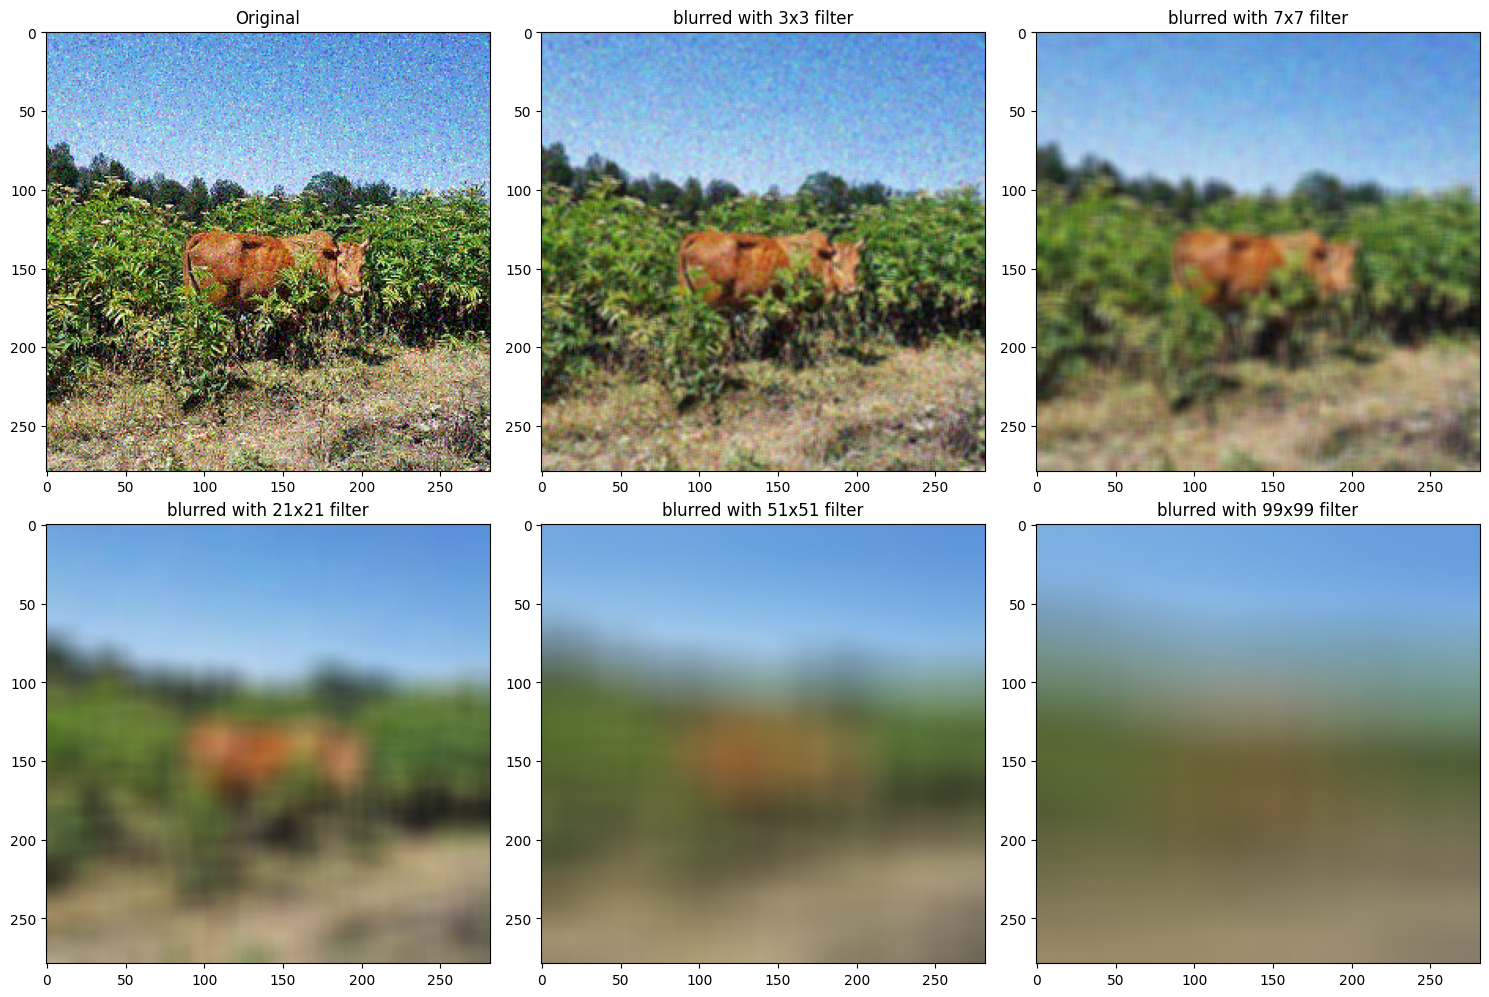

In [43]:
kernel_3x3 = np.ones((3,3), np.float32) / (3*3)
blurred = cv.filter2D(noisy_cow_img, -1, kernel_3x3)

kernel_7x7 = np.ones((7,7), np.float32) / (7*7)
blurred2 = cv.filter2D(noisy_cow_img, -1, kernel_7x7)

kernel_21x21 = np.ones((21,21), np.float32) / (21*21)
blurred3 = cv.filter2D(noisy_cow_img, -1, kernel_21x21)

kernel_51x51 = np.ones((51,51), np.float32) / (51*51)
blurred4 = cv.filter2D(noisy_cow_img, -1, kernel_51x51)

kernel_99x99 = np.ones((99,99), np.float32) / (99*99)
blurred5 = cv.filter2D(noisy_cow_img, -1, kernel_99x99)

plt.figure(figsize=[15,10])
plt.subplot(231);plt.imshow(noisy_cow_img[...,::-1]);plt.title("Original");
plt.subplot(232);plt.imshow(blurred[...,::-1]);plt.title("blurred with 3x3 filter");
plt.subplot(233);plt.imshow(blurred2[...,::-1]);plt.title("blurred with 7x7 filter");
plt.subplot(234);plt.imshow(blurred3[...,::-1]);plt.title("blurred with 21x21 filter");
plt.subplot(235);plt.imshow(blurred4[...,::-1]);plt.title("blurred with 51x51 filter");
plt.subplot(236);plt.imshow(blurred5[...,::-1]);plt.title("blurred with 99x99 filter");

plt.tight_layout()
plt.show()

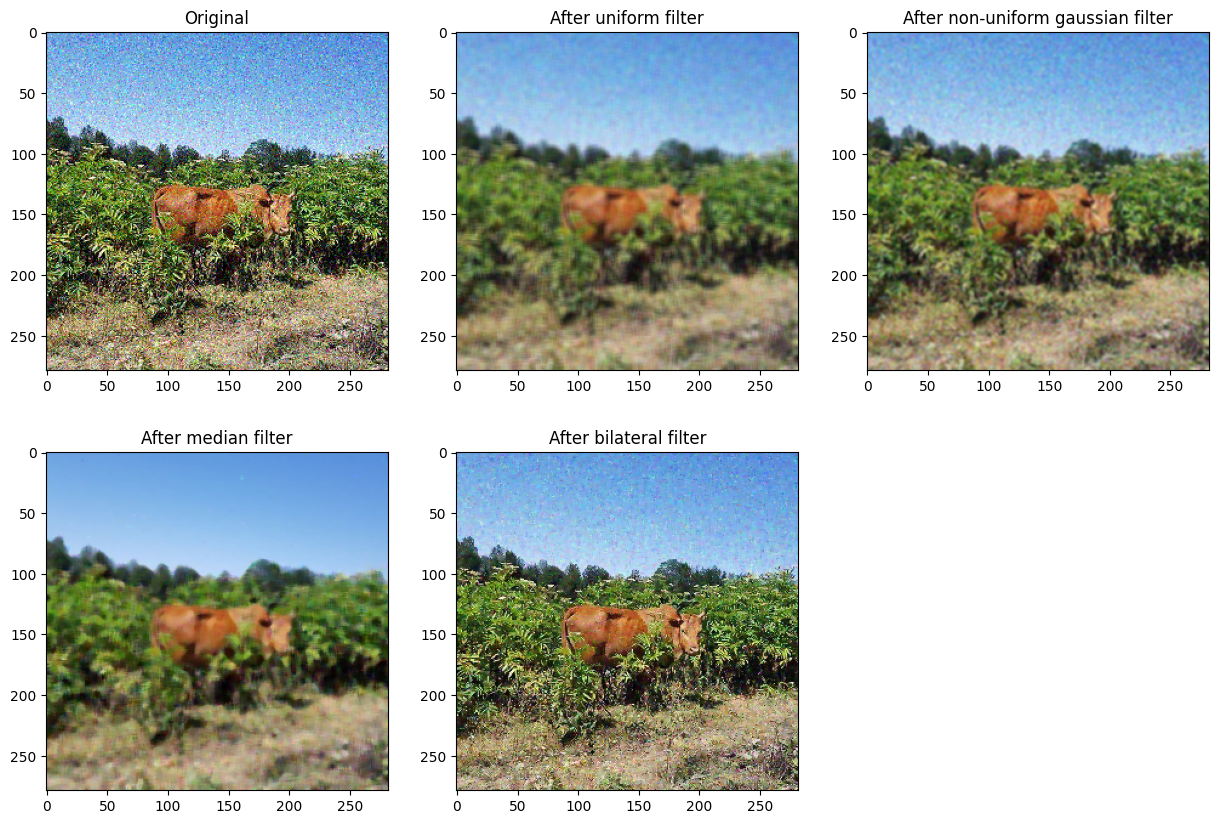

In [44]:
blur = cv.blur(noisy_cow_img, (5,5))

gaussian = cv.GaussianBlur(noisy_cow_img, (5,5), 0)

median = cv.medianBlur(noisy_cow_img, 5)

bilateral = cv.bilateralFilter(noisy_cow_img, 5, 75, 75)

plt.figure(figsize=[15,10])
plt.subplot(231);plt.imshow(noisy_cow_img[...,::-1]);plt.title("Original");
plt.subplot(232);plt.imshow(blur[...,::-1]);plt.title("After uniform filter");
plt.subplot(233);plt.imshow(gaussian[...,::-1]);plt.title("After non-uniform gaussian filter");
plt.subplot(234);plt.imshow(median[...,::-1]);plt.title("After median filter");
plt.subplot(235);plt.imshow(bilateral[...,::-1]);plt.title("After bilateral filter");

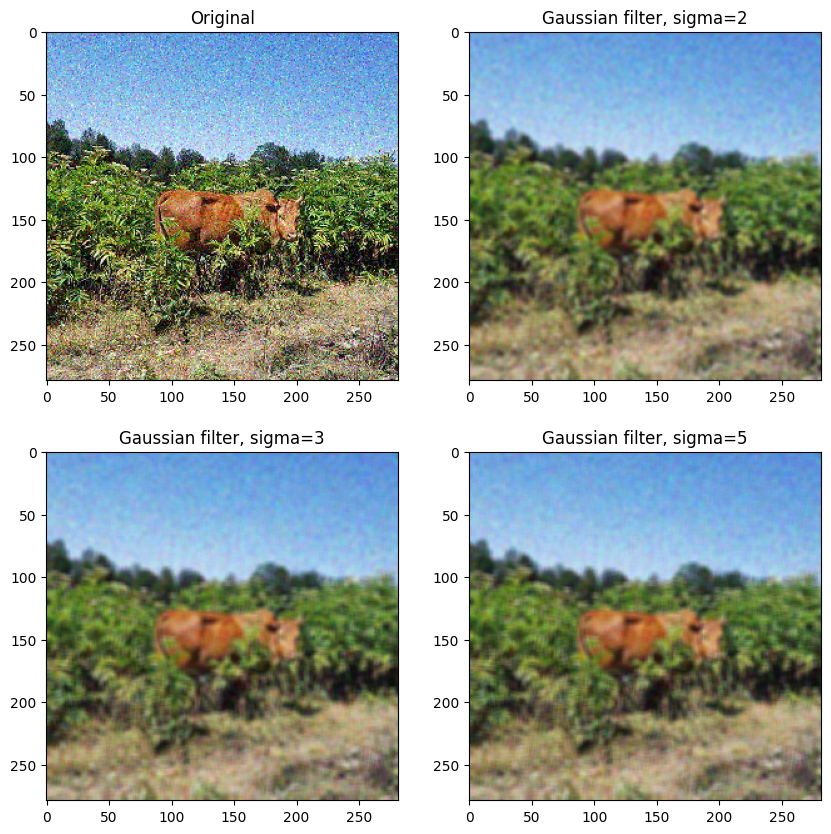

In [46]:
gaussian2 = cv.GaussianBlur(noisy_cow_img, (5, 5), 2)
gaussian3 = cv.GaussianBlur(noisy_cow_img, (5, 5), 3)
gaussian5 = cv.GaussianBlur(noisy_cow_img, (5, 5), 5)

plt.figure(figsize=[10,10])
plt.subplot(221);plt.imshow(noisy_cow_img[...,::-1]);plt.title("Original");
plt.subplot(222);plt.imshow(gaussian2[...,::-1]);plt.title("Gaussian filter, sigma=2");
plt.subplot(223);plt.imshow(gaussian3[...,::-1]);plt.title("Gaussian filter, sigma=3");
plt.subplot(224);plt.imshow(gaussian5[...,::-1]);plt.title("Gaussian filter, sigma=5");

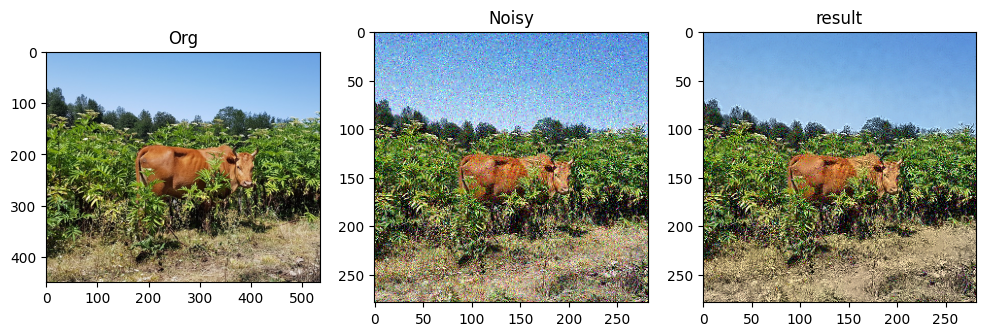

In [103]:
dst = cv.fastNlMeansDenoisingColored(noisy_cow_img,None,9,9,7, 7*7)

plt.figure(figsize=[12,10])
plt.subplot(131);plt.imshow(cow_img[100:550,115:650,::-1]);plt.title("Org");
plt.subplot(132);plt.imshow(noisy_cow_img[...,::-1]);plt.title("Noisy");
plt.subplot(133);plt.imshow(dst[...,::-1]);plt.title("result");